## Import packages and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geneinfo.coords import gene_coords
import geneinfo.information as gi
from geneinfo.genelist import GeneListCollection 
from geneinfo.genelist import GeneList as glist


In [38]:
LinARs_df = pd.read_csv("../data/adc9507_Data_S1.csv", sep=";", skiprows=2)
LinARs_df = LinARs_df.dropna(axis=1, how="all")

# Replace "06.sep" with "SEPT6"
LinARs_df['Gene_name'] = LinARs_df['Gene_name'].replace('06.sep', 'SEPT6')
sep_genes = {
    '05.sep': 'SEPT5',
    '06.sep': 'SEPT6',
    '09.sep': 'SEPT9',
    '14.sep': 'SEPT14',
    '11.sep': 'SEPT11',
    '07.sep': 'SEPT7',
    '03.sep': 'SEPT3',
    '01.sep': 'SEPT1',
    '04.sep': 'SEPT4',
    '08.sep': 'SEPT8',
}
LinARs_df['Gene_name'] = LinARs_df['Gene_name'].replace(sep_genes)

LinARs_df.head()

,Chr,Start,End,LinAR_ID,Nearest_Neighboring_Gene,lncRNA_ID,cCREs_ID,Gene_name,Lineage_name,PhyloP score,P-value,Q-value
0,chr3,82154474,82154736,HLinAR-Rank1,NONE,URS0000EBC6E1_9606,NONE,NONE,Human,"167,07914",0,0
1,chr21,8424934,8425419,HLinAR-Rank2,NONE,URS00019A85AC_9606,NONE,NONE,Human,"97,33254",0,0
2,chr20,63102113,63102273,HLinAR-Rank3*,ENSG00000149658,URS0000EF61E2_9606,EH38E2128905,YTHDF1,Human,"90,33879",0,0
3,chr21,8424387,8424860,HLinAR-Rank4,NONE,URS00019A85AC_9606,NONE,NONE,Human,"88,65024",0,0
4,chr21,8241960,8242395,HLinAR-Rank5,NONE,URS0001A07CFE_9606,NONE,NONE,Human,"81,2051",0,0


In [3]:
compartment_df = pd.read_csv("../data/chrX_compartments.csv", sep=",")
compartment_df.head()

,chrom,start,end,E1,compart
0,chrX,0,50000,NaN,B
1,chrX,50000,100000,NaN,B
2,chrX,100000,150000,NaN,B
3,chrX,150000,200000,NaN,B
4,chrX,200000,250000,NaN,B


## Compartment analysis

### Collapse compartment windows into true compartments

In [87]:
# Sort compartments
compartment_df = compartment_df.sort_values(["chrom", "start"]).reset_index(drop=True)

# Identify where a new compartment starts (new block starts at new chromosome or A/B label switch)
compartment_df["new_block"] = (
    (compartment_df["chrom"] != compartment_df["chrom"].shift()) |
    (compartment_df["compart"] != compartment_df["compart"].shift())
)

# Assign a compartment block ID 
compartment_df["block_id"] = compartment_df["new_block"].cumsum()

# Collapse compartments within the same block
collapsed_compartments = (
    compartment_df
    .groupby(["chrom", "block_id", "compart"], as_index=False)
    .agg(
        start=("start", "min"),
        end=("end", "max")
    )
)

print(collapsed_compartments.head())
print(len(collapsed_compartments))
print(f"Number of compartments: {len(collapsed_compartments)}")
print(collapsed_compartments["compart"].value_counts())



  chrom  block_id compart    start      end
0  chrX         1       B        0  2800000
1  chrX         2       A  2800000  3800000
2  chrX         3       B  3800000  3950000
3  chrX         4       A  3950000  4550000
4  chrX         5       B  4550000  4600000
323
Number of compartments: 323
compart
B    162
A    161
Name: count, dtype: int64


Mean compartment length: 483099 bp
Median compartment length: 100000 bp
Compartment length quantiles (bp):
0.25      50000.0
0.50     100000.0
0.75     200000.0
0.90     950000.0
0.95    1955000.0
0.99    8081000.0
Name: length, dtype: float64


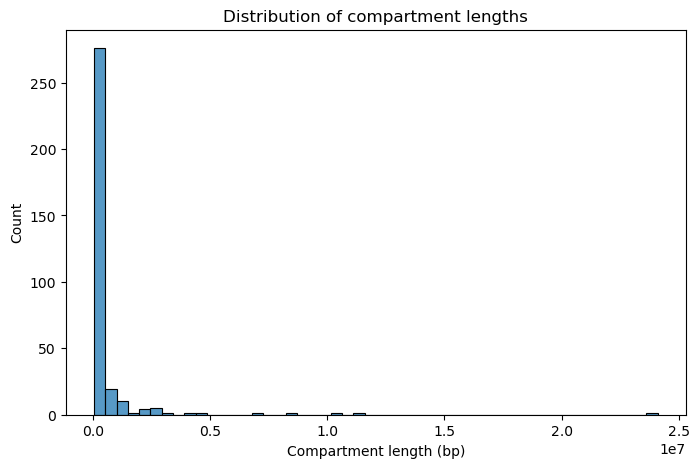

  compart    mean_length  median_length
0       A  488198.757764       100000.0
1       B  478030.216049       100000.0


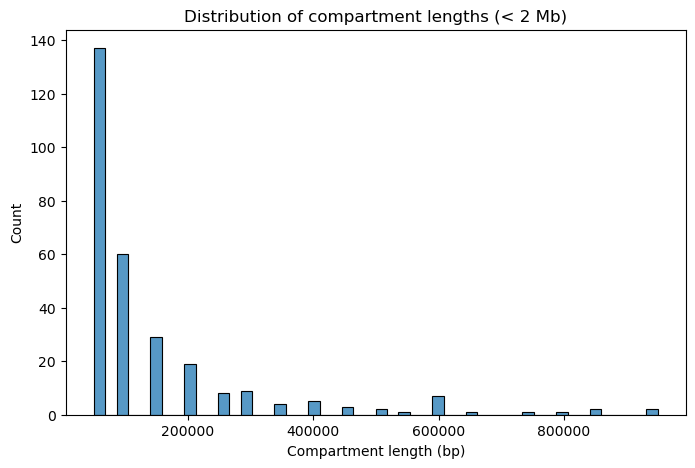

In [173]:
# Calculate compartment lengths
collapsed_compartments["length"] = collapsed_compartments["end"] - collapsed_compartments["start"]

# Calculate mean, median and quantiles of compartment lengths
mean_length = collapsed_compartments["length"].mean()
median_length = collapsed_compartments["length"].median()
quantiles = collapsed_compartments["length"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

print(f"Mean compartment length: {mean_length:.0f} bp")
print(f"Median compartment length: {median_length:.0f} bp")
print("Compartment length quantiles (bp):")
print(quantiles)


plt.figure(figsize=(8,5))
sns.histplot(
    data=collapsed_compartments,
    x="length",
    bins=50,
    edgecolor="black"
)
plt.xlabel("Compartment length (bp)")
plt.ylabel("Count")
plt.title("Distribution of compartment lengths")
plt.show()

# Calculate compartment lengths
collapsed_compartments["length"] = collapsed_compartments["end"] - collapsed_compartments["start"]

# Group by compartment type and calculate mean and median
compartment_stats = collapsed_compartments.groupby("compart")["length"].agg(
    mean_length="mean",
    median_length="median"
).reset_index()

print(compartment_stats)


# Zoom in on lengths less than 2 Mb
plt.figure(figsize=(8,5))
sns.histplot(
    data=collapsed_compartments[collapsed_compartments["length"] < 1000000],
    x="length",
    bins=50,
    edgecolor="black"
)
plt.xlabel("Compartment length (bp)")
plt.ylabel("Count")
plt.title("Distribution of compartment lengths (< 2 Mb)")
plt.show()

### Calculate distance between LinARs and compartments on chr X

         LinAR_ID   Chr  Start_LinAR  End_LinAR Lineage_name Gene_name  \
0  HLinAR-Rank56*  chrX    138710262  138711758        Human     FGF13   
1   HLinAR-Rank87  chrX    103910029  103910206        Human   TMSB15B   
2  HLinAR-Rank157  chrX     71910623   71911026        Human     NHSL2   
3  HLinAR-Rank220  chrX    139142129  139142405        Human     FGF13   
4  HLinAR-Rank234  chrX    116107686  116108025        Human     AGTR2   

  Compartment  Compartment_start  Compartment_end  \
0           B        138700000.0      138750000.0   
1           B        103150000.0      104000000.0   
2           A         71800000.0       72750000.0   
3           A        139050000.0      139150000.0   
4           B        115450000.0      116700000.0   

   Distance_to_compartment_border  
0                           10262  
1                           89794  
2                          110623  
3                            7595  
4                          591975  


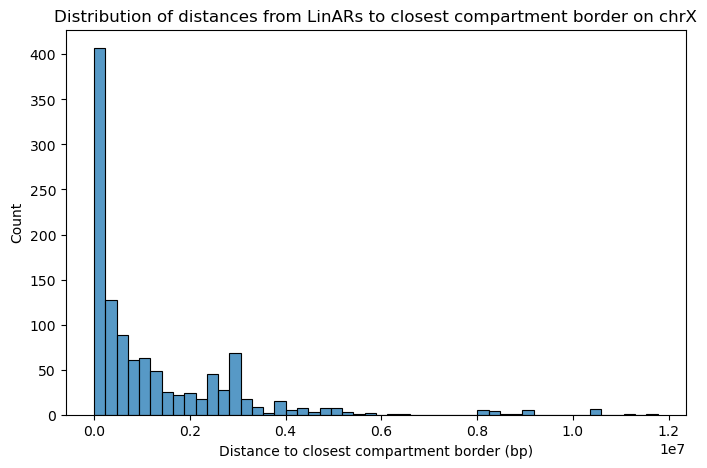

In [127]:
# Calculate the distance between a chrX LinAR and all compartments on chrX, store the compartment with the smallest distance

# Keep only LinARs on chromosome X
apes = ["Human", "Pan troglodytes", "Pan paniscus", "Gorilla gorilla", "Pongo abelii", "Pongo pygmaeus", "Nomascus siki", "Symphalangus syndactylus", "Hoolock leuconedys", "Hylobates pileatus", "Homininae", "Ponginae", "Hylobatidae", "Hominidae", "Hominoidea"]
ape_LinARs_df = LinARs_df[LinARs_df["Lineage_name"].isin(apes)]
ape_LinARs_chrX = ape_LinARs_df[ape_LinARs_df["Chr"] == "chrX"].copy()

# Keep only compartments on chromosome X
compartment_chrX = collapsed_compartments[collapsed_compartments["chrom"] == "chrX"].copy()

results = []

for i, LinAR in ape_LinARs_chrX.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find all compartments that the LinAR overlaps 
    overlapping_compartments = compartment_chrX[
        (LinAR_start < compartment_chrX['end']) & (LinAR_end > compartment_chrX['start'])
    ]

    if len(overlapping_compartments) > 1:
        # LinAR overlaps more than one compartment -> crosses border -> distance = 0
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan
    else:
        # LinAR overlaps exactly one compartment
        compartment = overlapping_compartments.iloc[0]

         # Fully inside one compartment
        distance_to_start = LinAR_start - compartment["start"]
        distance_to_end   = compartment["end"] - LinAR_end
        distance_to_border = min(distance_to_start, distance_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]

    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': LinAR['Chr'],
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Gene_name': LinAR['Gene_name'],
        'Compartment': compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)
print(linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX")
plt.show()


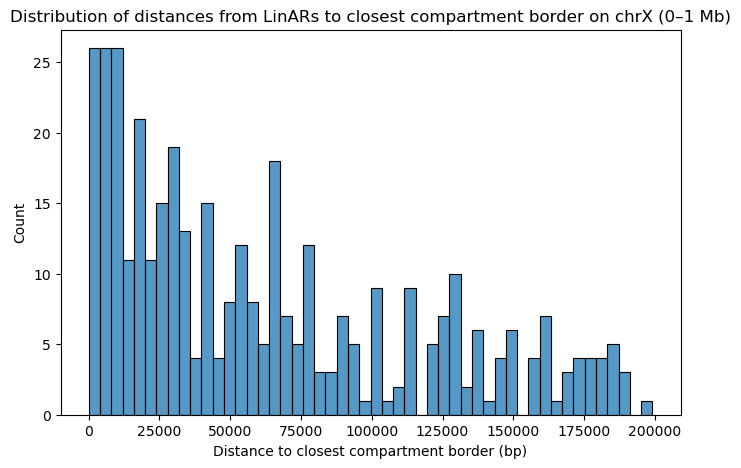

In [92]:
# Filter distances
subset_df = linar_compartment_border_distances[
    (linar_compartment_border_distances['Distance_to_compartment_border'] >= 0) &
    (linar_compartment_border_distances['Distance_to_compartment_border'] <= 200000)
]

plt.figure(figsize=(8,5))
sns.histplot(
    data=subset_df,
    x='Distance_to_compartment_border',
    bins=50,  
    kde=False,
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX (0–1 Mb)")
plt.show()


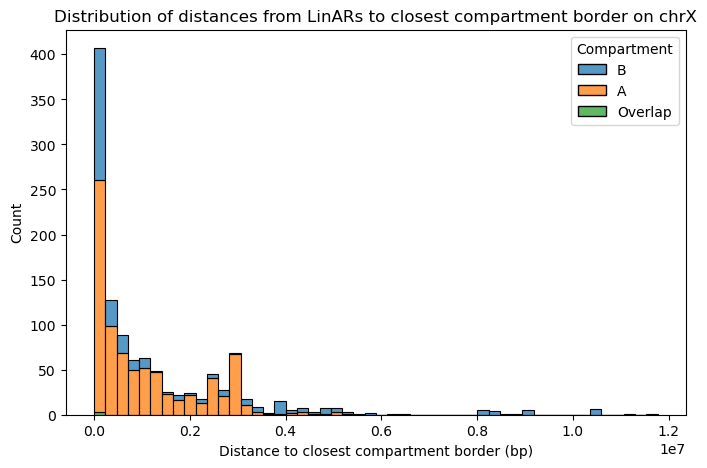

Compartment
A          0.711249
B          0.286094
Overlap    0.002657
Name: count, dtype: float64
  Compartment  mean_distance  median_distance
0           A   1.055173e+06         609196.0
1           B   1.739615e+06         348441.0


In [128]:
# Color by compartment
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    hue='Compartment', 
    bins=50, 
    multiple='stack',
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX")
plt.show()

# Calculate the proportion of LinARs in A and B compartments
compartment_counts = linar_compartment_border_distances['Compartment'].value_counts()
total_counts = compartment_counts.sum()
compartment_proportions = compartment_counts / total_counts
print(compartment_proportions)

# Group by compartment and calculate mean and median
linar_inside = linar_compartment_border_distances[
    linar_compartment_border_distances["Compartment"].isin(["A", "B"])
].copy()
compartment_stats = linar_inside.groupby("Compartment")["Distance_to_compartment_border"].agg(
    mean_distance="mean",
    median_distance="median"
).reset_index()
print(compartment_stats)



In [ ]:
# Count LinARs that crossses borders

(linar_compartment_border_distances["Distance_to_compartment_border"] == 0).sum()


np.int64(3)

### Calculate distance between unique LinARs and compartments on chr X

         LinAR_ID   Chr  Start_LinAR  End_LinAR Lineage_name Gene_name  \
0  HLinAR-Rank56*  chrX    138710262  138711758        Human     FGF13   
1   HLinAR-Rank87  chrX    103910029  103910206        Human   TMSB15B   
2  HLinAR-Rank157  chrX     71910623   71911026        Human     NHSL2   
3  HLinAR-Rank220  chrX    139142129  139142405        Human     FGF13   
4  HLinAR-Rank234  chrX    116107686  116108025        Human     AGTR2   

  Compartment  Compartment_start  Compartment_end  \
0           B        138700000.0      138750000.0   
1           B        103150000.0      104000000.0   
2           A         71800000.0       72750000.0   
3           A        139050000.0      139150000.0   
4           B        115450000.0      116700000.0   

   Distance_to_compartment_border  
0                           10262  
1                           89794  
2                          110623  
3                            7595  
4                          591975  


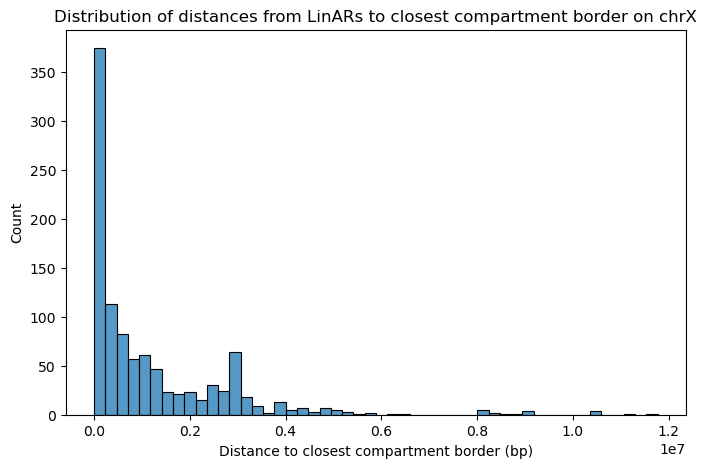

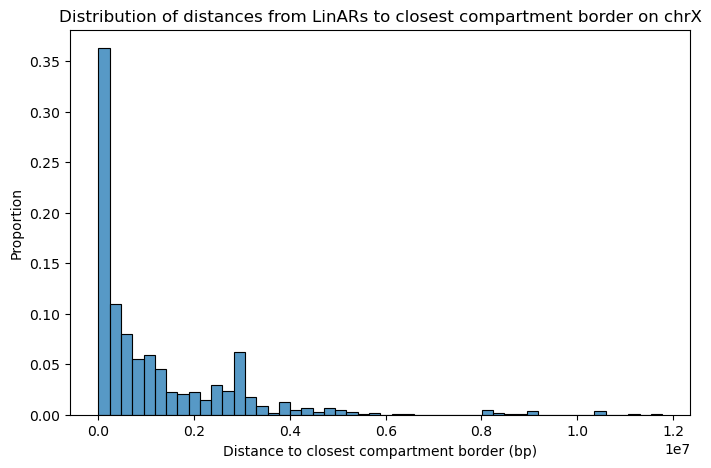

In [161]:
ape_LinARs_chrX_unique = ape_LinARs_chrX.drop_duplicates(
    subset=["Chr", "Start", "End"]).copy()

results = []

for i, LinAR in ape_LinARs_chrX_unique.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find all compartments that the LinAR overlaps 
    overlapping_compartments = compartment_chrX[
        (LinAR_start < compartment_chrX['end']) & (LinAR_end > compartment_chrX['start'])
    ]

    if len(overlapping_compartments) > 1:
        # LinAR overlaps more than one compartment -> crosses border -> distance = 0
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan
    else:
        # LinAR overlaps exactly one compartment
        compartment = overlapping_compartments.iloc[0]

         # Fully inside one compartment
        distance_to_start = LinAR_start - compartment["start"]
        distance_to_end   = compartment["end"] - LinAR_end
        distance_to_border = min(distance_to_start, distance_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]

    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': LinAR['Chr'],
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR.get('Lineage_name'),
        'Gene_name': LinAR['Gene_name'],
        'Compartment': compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


linar_compartment_border_distances = pd.DataFrame(results)
print(linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances,
    x="Distance_to_compartment_border",
    bins=50,
    edgecolor="black",
    stat="probability"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Proportion")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX")
plt.show()


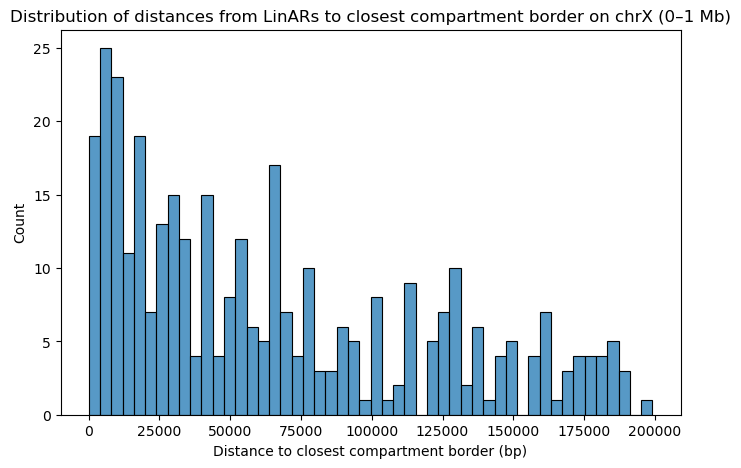

In [162]:
# Filter distances 
subset_df = linar_compartment_border_distances[
    (linar_compartment_border_distances['Distance_to_compartment_border'] >= 0) &
    (linar_compartment_border_distances['Distance_to_compartment_border'] <= 200000)
]

plt.figure(figsize=(8,5))
sns.histplot(
    data=subset_df,
    x='Distance_to_compartment_border',
    bins=50,       
    kde=False,
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX (0–1 Mb)")
plt.show()


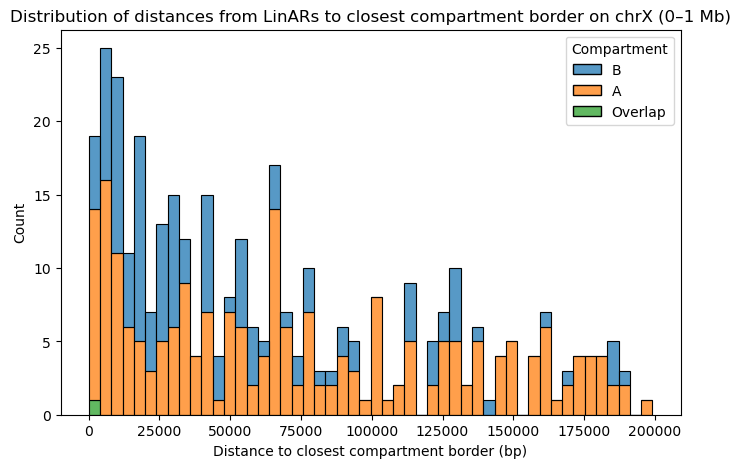

In [175]:
# Filter distances 
subset_df = linar_compartment_border_distances[
    (linar_compartment_border_distances['Distance_to_compartment_border'] >= 0) &
    (linar_compartment_border_distances['Distance_to_compartment_border'] <= 200000)
]

plt.figure(figsize=(8,5))
sns.histplot(
    data=subset_df,
    x='Distance_to_compartment_border',
    hue='Compartment',
    bins=50,       
    kde=False,
    multiple='stack',
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX (0–1 Mb)")
plt.show()

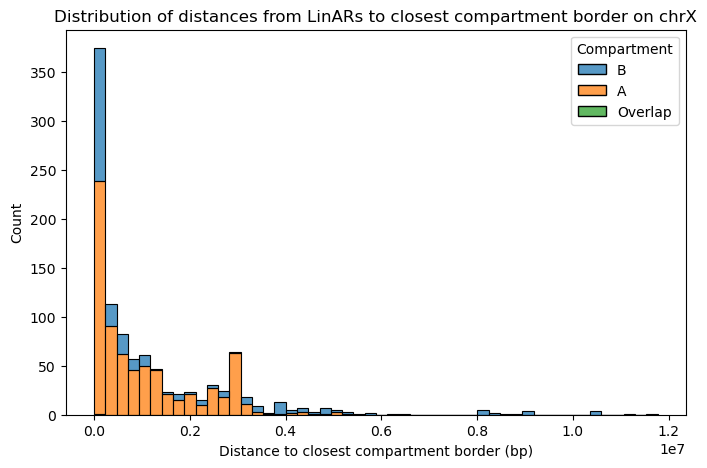

Compartment
A          0.712621
B          0.286408
Overlap    0.000971
Name: count, dtype: float64


In [163]:
# Color by compartment
plt.figure(figsize=(8,5))
sns.histplot(
    data=linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    hue='Compartment', 
    bins=50, 
    multiple='stack',
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from LinARs to closest compartment border on chrX")
plt.show()

# Calculate the proportion of LinARs in A and B compartments
compartment_counts = linar_compartment_border_distances['Compartment'].value_counts()
total_counts = compartment_counts.sum()
compartment_proportions = compartment_counts / total_counts
print(compartment_proportions)


In [ ]:
# Number of LinARs that cross compartment borders
(linar_compartment_border_distances["Distance_to_compartment_border"] == 0).sum()


np.int64(1)

In [41]:
len(ape_LinARs_chrX), len(ape_LinARs_chrX_unique)


(1129, 1030)

### Simulated distances

   Distance_to_compartment_border
0                       1288020.0
1                       2686314.0
2                       1039479.0
3                       3118219.0
4                          9482.0


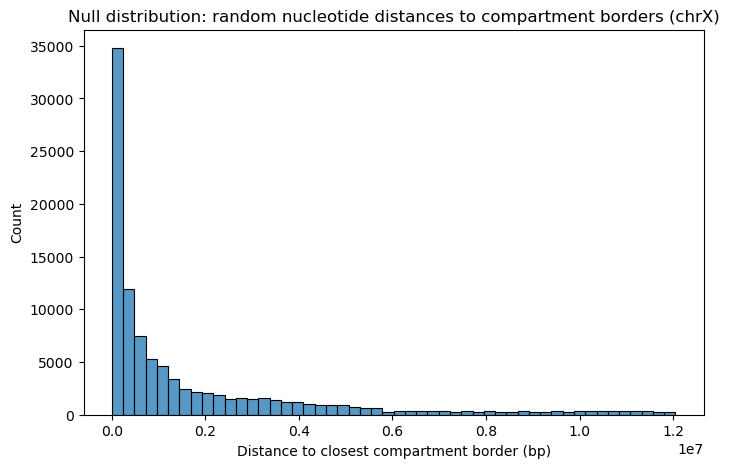

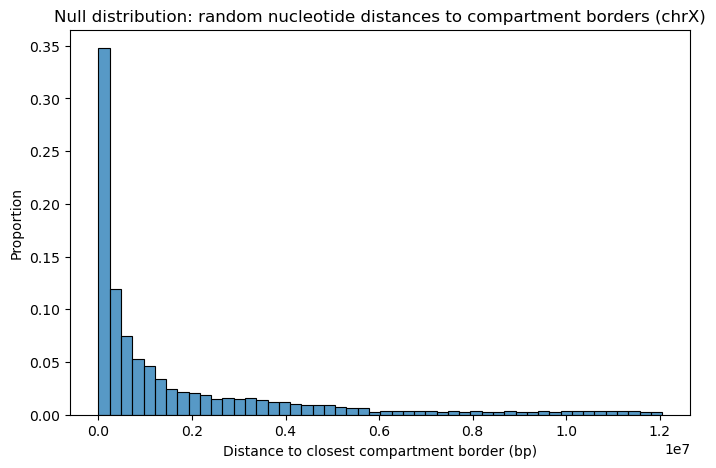

In [154]:
# Simulate null distribution of distances from random chrX positions to compartment borders

x_chrom_length = 156040895

# All compartment border positions
borders = np.sort(
    np.concatenate([
        compartment_chrX["start"].values,
        compartment_chrX["end"].values
    ])
)

# Number of random positions
n_random = 100000

# Sample random single-nucleotide positions
random_positions = np.random.randint(0, x_chrom_length, size=n_random) 

#  Distance to nearest border 
border_idx = np.searchsorted(borders, random_positions) # At what index would this value be inserted into borders to keep it sorted. Gives you the border to the right and left

# Distance to left border
left_dist = np.where(
    border_idx > 0,
    np.abs(random_positions - borders[border_idx - 1]),
    np.inf
)
# Distance to right border
right_dist = np.where(
    border_idx < len(borders),
    np.abs(borders[border_idx] - random_positions),
    np.inf
)

distance_to_border = np.minimum(left_dist, right_dist)

random_distances_df = pd.DataFrame({"Distance_to_compartment_border": distance_to_border})

print(random_distances_df.head())


plt.figure(figsize=(8,5))
sns.histplot(
    data=random_distances_df,
    x="Distance_to_compartment_border",
    bins=50,
    edgecolor="black"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Null distribution: random nucleotide distances to compartment borders (chrX)")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(
    data=random_distances_df,
    x="Distance_to_compartment_border",
    bins=50,
    edgecolor="black",
    stat="probability"  
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Proportion")
plt.title("Null distribution: random nucleotide distances to compartment borders (chrX)")
plt.show()






         LinAR_ID   Chr  Start_LinAR  End_LinAR Lineage_name Gene_name  \
0  HLinAR-Rank56*  chrX    151159274  151160770        Human     FGF13   
1   HLinAR-Rank87  chrX     67667445   67667622        Human   TMSB15B   
2  HLinAR-Rank157  chrX    120364289  120364692        Human     NHSL2   
3  HLinAR-Rank220  chrX    119652278  119652554        Human     FGF13   
4  HLinAR-Rank234  chrX    117915136  117915475        Human     AGTR2   

  Compartment  Compartment_start  Compartment_end  \
0           A          149950000        152650000   
1           A           63250000         71650000   
2           A          120350000        120500000   
3           B          119600000        119700000   
4           B          117000000        118050000   

   Distance_to_compartment_border  
0                         1209274  
1                         3982378  
2                           14289  
3                           47446  
4                          134525  


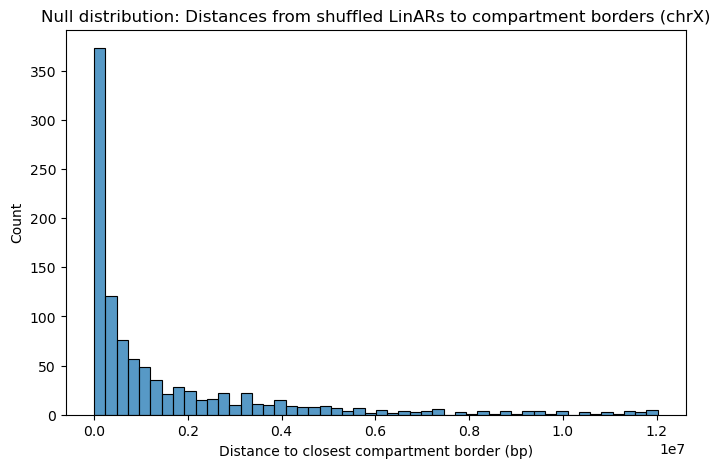

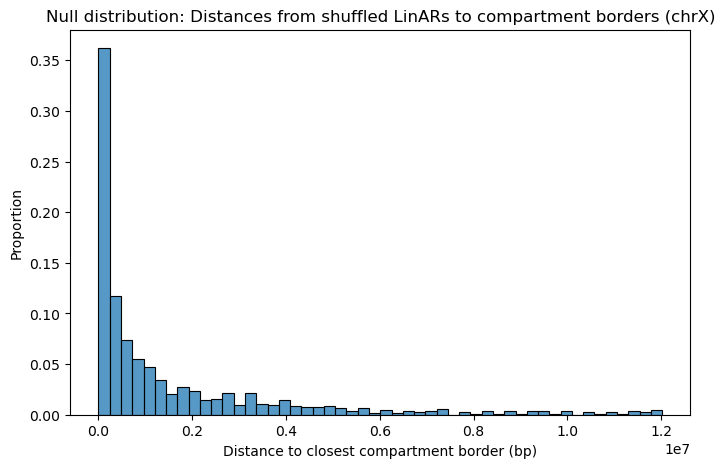

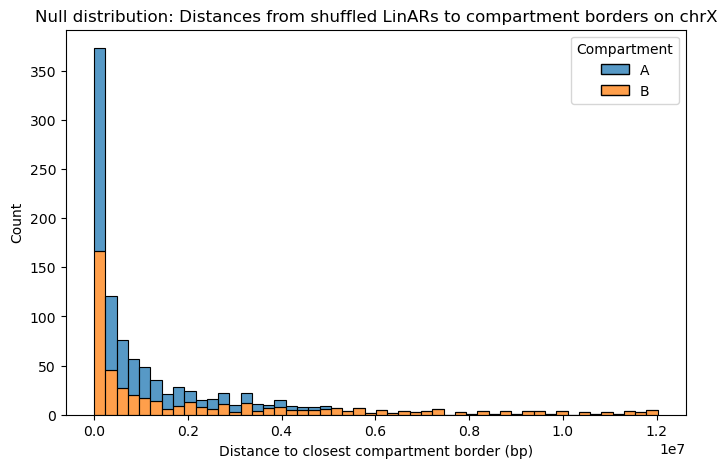

  Compartment  mean_distance  median_distance
0           A   9.140957e+05         433289.0
1           B   2.392320e+06         765592.5


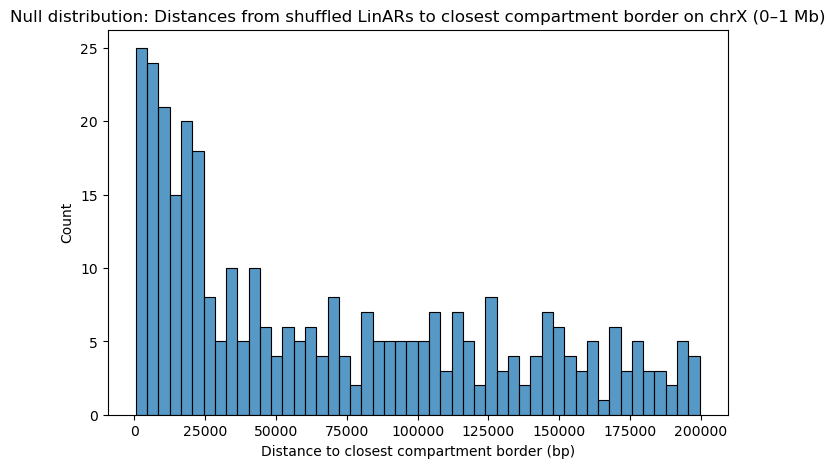

In [169]:
# Simulate null distribution of distances from shuffled LinARs to compartment borders

# Shuffle LinAR positions on chrX
shuffled_LinARs = []
for _, LinAR in ape_LinARs_chrX_unique.iterrows():
    length = LinAR["End"] - LinAR["Start"]
    random_start = np.random.randint(0, x_chrom_length - length)
    random_end = random_start + length
    shuffled_LinARs.append({
        "LinAR_ID": LinAR["LinAR_ID"],
        "Chr": "chrX",
        "Start": random_start,
        "End": random_end,
        "Lineage_name": LinAR.get("Lineage_name"),
        "Gene_name": LinAR.get("Gene_name")
    })
shuffled_linars_df = pd.DataFrame(shuffled_LinARs)

# Calculate distances from shuffled LinARs to compartment borders
shuffled_distance_results = []
for _, LinAR in shuffled_linars_df.iterrows():
    LinAR_start = LinAR["Start"]
    LinAR_end = LinAR["End"]

    overlapping_compartments = compartment_chrX[(LinAR_start < compartment_chrX['end']) & (LinAR_end > compartment_chrX['start'])]

    if len(overlapping_compartments) > 1:
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan
    else:
        compartment = overlapping_compartments.iloc[0]
        distance_to_start = LinAR_start - compartment["start"]
        distance_to_end   = compartment["end"] - LinAR_end
        distance_to_border = min(distance_to_start, distance_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]


    shuffled_distance_results.append({
        "LinAR_ID": LinAR["LinAR_ID"],
        "Chr": LinAR["Chr"],
        "Start_LinAR": LinAR_start,
        "End_LinAR": LinAR_end,
        "Lineage_name": LinAR.get("Lineage_name"),
        "Gene_name": LinAR.get("Gene_name"),
        "Compartment": compartment_type,
        "Compartment_start": compartment_start,
        "Compartment_end": compartment_end,
        "Distance_to_compartment_border": distance_to_border
    })

shuffled_linar_compartment_distances = pd.DataFrame(shuffled_distance_results)
print(shuffled_linar_compartment_distances.head())

plt.figure(figsize=(8,5))
sns.histplot(
    data=shuffled_linar_compartment_distances,
    x="Distance_to_compartment_border",
    bins=50,
    kde=False,
    edgecolor="black"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Null distribution: Distances from shuffled LinARs to compartment borders (chrX)")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(
    data=shuffled_linar_compartment_distances,
    x="Distance_to_compartment_border",
    bins=50,
    edgecolor="black",
    stat="probability"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Proportion")
plt.title("Null distribution: Distances from shuffled LinARs to compartment borders (chrX)")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(
    data=shuffled_linar_compartment_distances, 
    x='Distance_to_compartment_border', 
    hue='Compartment', 
    bins=50, 
    multiple='stack',
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Null distribution: Distances from shuffled LinARs to compartment borders on chrX")
plt.show()


# Group by compartment and calculate mean and median
linar_inside = shuffled_linar_compartment_distances[
    shuffled_linar_compartment_distances["Compartment"].isin(["A", "B"])
].copy()
compartment_stats = linar_inside.groupby("Compartment")["Distance_to_compartment_border"].agg(
    mean_distance="mean",
    median_distance="median"
).reset_index()
print(compartment_stats)


# Filter distances 
subset_df = shuffled_linar_compartment_distances[
    (shuffled_linar_compartment_distances['Distance_to_compartment_border'] >= 0) &
    (shuffled_linar_compartment_distances['Distance_to_compartment_border'] <= 200000)
]
plt.figure(figsize=(8,5))
sns.histplot(
    data=subset_df,
    x='Distance_to_compartment_border',
    bins=50,       
    kde=False,
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Null distribution: Distances from shuffled LinARs to closest compartment border on chrX (0–1 Mb)")
plt.show()

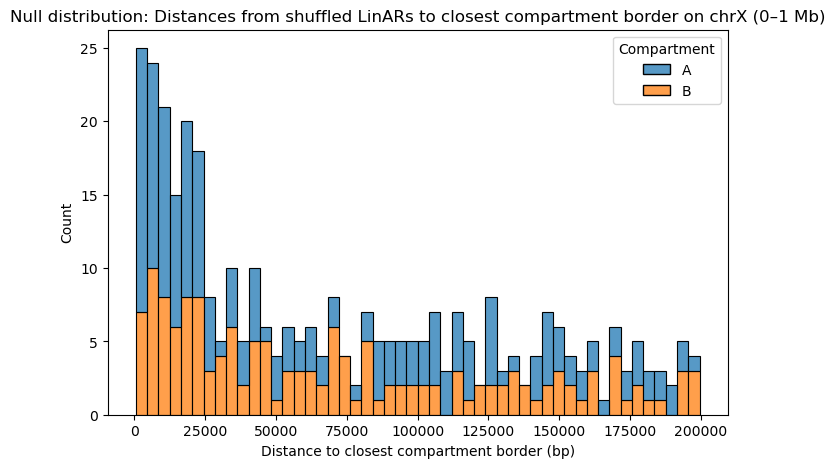

In [177]:
# Filter distances 
subset_df = shuffled_linar_compartment_distances[
    (shuffled_linar_compartment_distances['Distance_to_compartment_border'] >= 0) &
    (shuffled_linar_compartment_distances['Distance_to_compartment_border'] <= 200000)
]
plt.figure(figsize=(8,5))
sns.histplot(
    data=subset_df,
    x='Distance_to_compartment_border',
    hue='Compartment', 
    bins=50, 
    multiple='stack',
    edgecolor='black',
    kde=False)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Null distribution: Distances from shuffled LinARs to closest compartment border on chrX (0–1 Mb)")
plt.show()

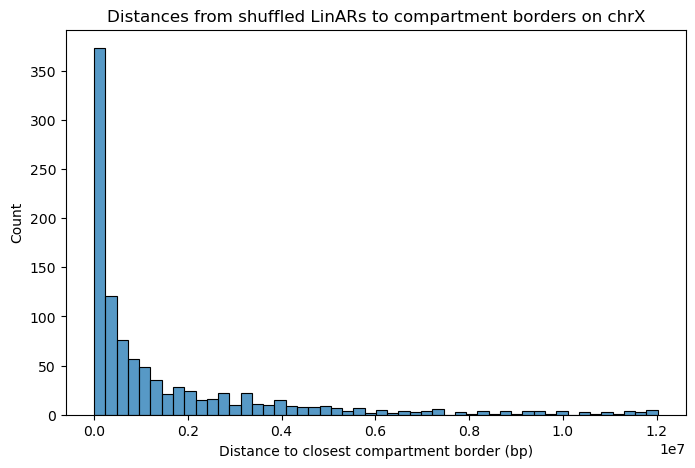

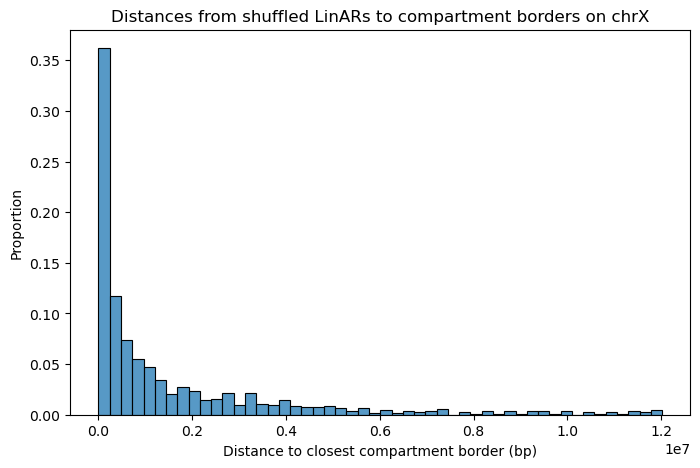

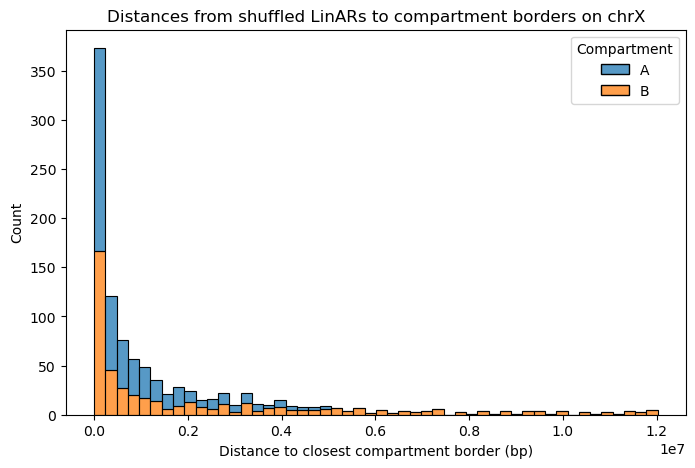

  Compartment  mean_distance  median_distance
0           A   9.140957e+05         433289.0
1           B   2.392320e+06         765592.5


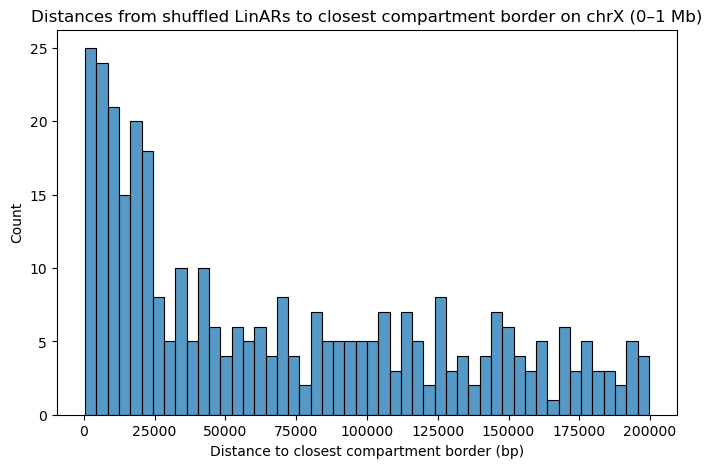

In [174]:

plt.figure(figsize=(8,5))
sns.histplot(
    data=shuffled_linar_compartment_distances,
    x="Distance_to_compartment_border",
    bins=50,
    kde=False,
    edgecolor="black"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distances from shuffled LinARs to compartment borders on chrX")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(
    data=shuffled_linar_compartment_distances,
    x="Distance_to_compartment_border",
    bins=50,
    edgecolor="black",
    stat="probability"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Proportion")
plt.title("Distances from shuffled LinARs to compartment borders on chrX")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(
    data=shuffled_linar_compartment_distances, 
    x='Distance_to_compartment_border', 
    hue='Compartment', 
    bins=50, 
    multiple='stack',
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distances from shuffled LinARs to compartment borders on chrX")
plt.show()


# Group by compartment and calculate mean and median
linar_inside = shuffled_linar_compartment_distances[
    shuffled_linar_compartment_distances["Compartment"].isin(["A", "B"])
].copy()
compartment_stats = linar_inside.groupby("Compartment")["Distance_to_compartment_border"].agg(
    mean_distance="mean",
    median_distance="median"
).reset_index()
print(compartment_stats)


# Filter distances 
subset_df = shuffled_linar_compartment_distances[
    (shuffled_linar_compartment_distances['Distance_to_compartment_border'] >= 0) &
    (shuffled_linar_compartment_distances['Distance_to_compartment_border'] <= 200000)
]
plt.figure(figsize=(8,5))
sns.histplot(
    data=subset_df,
    x='Distance_to_compartment_border',
    bins=50,       
    kde=False,
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distances from shuffled LinARs to closest compartment border on chrX (0–1 Mb)")
plt.show()

### Compare expected with observed

Observed mean distance to compartment border: 1220853.178814383
Expected mean distance to compartment border: 1381510.051020408
p-value: 0.054607497853312946


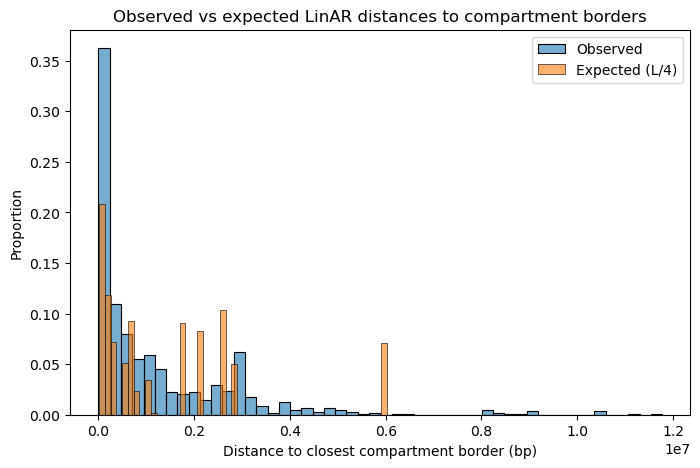

In [126]:
# Quick check: Compare observed mean vs expected mean (theoretical mean = 1/4 of compartment length)

# Only keep LinARs fully inside one compartment (not overlaps)
linar_inside_compartment_df = linar_compartment_border_distances[
    linar_compartment_border_distances["Compartment"].isin(["A", "B"])
].copy()

# Calculate observed mean distance
observed_mean = linar_inside_compartment_df["Distance_to_compartment_border"].mean()

# Calculate expected mean distance (1/4 of compartment length)
expected_mean = (
    (linar_inside_compartment_df["Compartment_end"] - linar_inside_compartment_df["Compartment_start"]) / 4
).mean()


print("Observed mean distance to compartment border:", observed_mean)
print("Expected mean distance to compartment border:", expected_mean)


# Statistical test 

from scipy.stats import wilcoxon

expected_distances = (linar_inside_compartment_df["Compartment_end"] - linar_inside_compartment_df["Compartment_start"]) / 4

stat, p_value = wilcoxon(
    linar_inside_compartment_df["Distance_to_compartment_border"],
    expected_distances,
    alternative="less"  
)

print("p-value:", p_value)



# Plot observed vs expected distributions:

plt.figure(figsize=(8,5))
sns.histplot(
    linar_inside_compartment_df["Distance_to_compartment_border"],
    bins=50,
    stat="probability",
    alpha=0.6,
    edgecolor="black",
    label="Observed"
)
sns.histplot(
    expected_distances,
    bins=50,
    stat="probability",
    alpha=0.6,
    edgecolor="black",
    label="Expected (L/4)"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Proportion")
plt.title("Observed vs expected LinAR distances to compartment borders")
plt.legend()
plt.show()





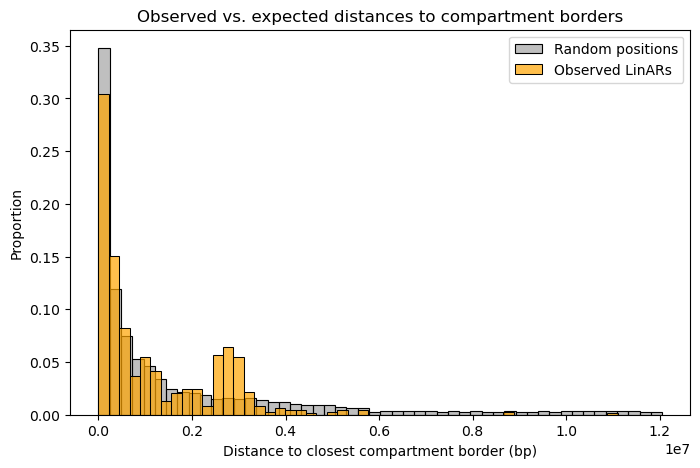

Observed mean: 1175742.602960969, Null mean: 1737619.58701
Observed median: 543796.0, Null median: 573085.0
p-value: 0.12858696854176815


In [157]:
# Calcualted distances comparison (nucleotide distances)

plt.figure(figsize=(8,5))
sns.histplot(
    data=random_distances_df,
    x="Distance_to_compartment_border",
    bins=50,
    stat="probability",
    color="gray",
    alpha=0.5,
    label="Random positions"
)
sns.histplot(
    data=linar_compartment_border_distances,
    x="Distance_to_compartment_border",
    bins=50,
    stat="probability",
    color="orange",
    alpha=0.7,
    label="Observed LinARs"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Proportion")
plt.title("Observed vs. expected distances to compartment borders")
plt.legend()
plt.show()


# Mean and median distances

observed_mean = linar_compartment_border_distances["Distance_to_compartment_border"].mean()
null_mean = random_distances_df["Distance_to_compartment_border"].mean()
print(f"Observed mean: {observed_mean}, Null mean: {null_mean}")

observed_median = linar_compartment_border_distances["Distance_to_compartment_border"].median()
null_median = random_distances_df["Distance_to_compartment_border"].median()
print(f"Observed median: {observed_median}, Null median: {null_median}")


# Mann-Whitney U test between observed and shuffled LinAR distances

from scipy.stats import mannwhitneyu

obs_distances = linar_compartment_border_distances["Distance_to_compartment_border"]
null_distances = random_distances_df["Distance_to_compartment_border"]

u_stat, p_value = mannwhitneyu(
    obs_distances,
    null_distances,
    alternative="less"  # observed distances are smaller
)
print("p-value:", p_value)





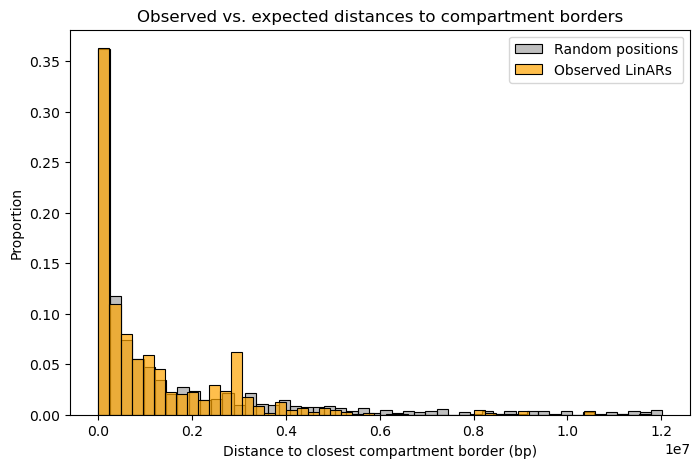

Observed mean: 1219667.8844660195, Null mean: 1617328.8019417475
Observed median: 537203.5, Null median: 532740.0
p-value: 0.08116121816143446


In [170]:
# Calcualted distances comparison (shuffled LinARs)

plt.figure(figsize=(8,5))
sns.histplot(
    data=shuffled_linar_compartment_distances,
    x="Distance_to_compartment_border",
    bins=50,
    stat="probability",
    color="gray",
    alpha=0.5,
    label="Random positions"
)
sns.histplot(
    data=linar_compartment_border_distances,
    x="Distance_to_compartment_border",
    bins=50,
    stat="probability",
    color="orange",
    alpha=0.7,
    label="Observed LinARs"
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Proportion")
plt.title("Observed vs. expected distances to compartment borders")
plt.legend()
plt.show()


# Mean and median distances

observed_mean = linar_compartment_border_distances["Distance_to_compartment_border"].mean()
null_mean = shuffled_linar_compartment_distances["Distance_to_compartment_border"].mean()
print(f"Observed mean: {observed_mean}, Null mean: {null_mean}")

observed_median = linar_compartment_border_distances["Distance_to_compartment_border"].median()
null_median = shuffled_linar_compartment_distances["Distance_to_compartment_border"].median()
print(f"Observed median: {observed_median}, Null median: {null_median}")


# Mann-Whitney U test between observed and shuffled LinAR distances


obs_distances = linar_compartment_border_distances["Distance_to_compartment_border"]
null_distances = shuffled_linar_compartment_distances["Distance_to_compartment_border"]

u_stat, p_value = mannwhitneyu(
    obs_distances,
    null_distances,
    alternative="less"  # observed distances are smaller
)
print("p-value:", p_value)



Observed mean distance: 1219668 bp
Mean of permuted distances: 1738076 bp
Empirical p-value: 0.0010


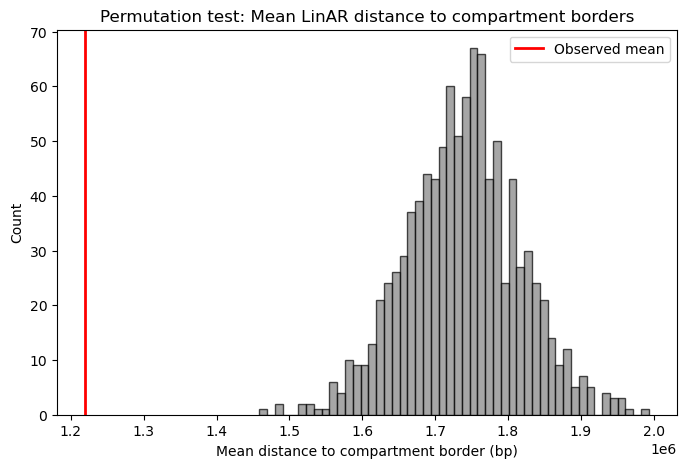

In [ ]:
# Permutation test with shuffled LinARs (mean)

# Number of permutations
n_perm = 1000
x_chrom_length = 156040895

observed_distances = linar_compartment_border_distances["Distance_to_compartment_border"].values
observed_mean = observed_distances.mean()

perm_means = []

for perm in range(n_perm):
    shuffled_distances = []

    for _, LinAR in ape_LinARs_chrX_unique.iterrows():
        length = LinAR["End"] - LinAR["Start"]
        random_start = np.random.randint(0, x_chrom_length - length)
        random_end = random_start + length

        overlapping_compartments = compartment_chrX[
            (random_start < compartment_chrX['end']) &
            (random_end > compartment_chrX['start'])
        ]

        if len(overlapping_compartments) > 1:
            distance_to_border = 0
        else:
            compartment = overlapping_compartments.iloc[0]
            distance_to_start = random_start - compartment["start"]
            distance_to_end   = compartment["end"] - random_end
            distance_to_border = min(distance_to_start, distance_to_end)

        shuffled_distances.append(distance_to_border)

    perm_means.append(np.mean(shuffled_distances))

perm_means = np.array(perm_means)


# Plot permutation distribution
plt.figure(figsize=(8,5))
plt.hist(perm_means, bins=50, color='gray', alpha=0.7, edgecolor='black')
plt.axvline(observed_mean, color='red', linewidth=2, label='Observed mean')
plt.xlabel("Mean distance to compartment border (bp)")
plt.ylabel("Count")
plt.title("Permutation test: Mean LinAR distance to compartment borders")
plt.legend()
plt.show()


In [180]:
print(f"Observed mean distance: {observed_mean:.0f} bp")
print(f"Mean of permuted mean distances: {np.mean(perm_means):.0f} bp")
print(f"Median of permuted mean distances: {np.median(perm_means):.0f} bp")


# Empirical p-value: fraction of permuted means <= observed mean
p_value = (np.sum(perm_means <= observed_mean) + 1) / (n_perm + 1)
print(f"Empirical p-value: {p_value:.4f}")


Observed mean distance: 1219668 bp
Mean of permuted mean distances: 1738076 bp
Median of permuted mean distances: 1740110 bp
Empirical p-value: 0.0010


Observed median distance: 537204 bp
Median of permuted distances: 578931 bp
Empirical p-value: 0.1998


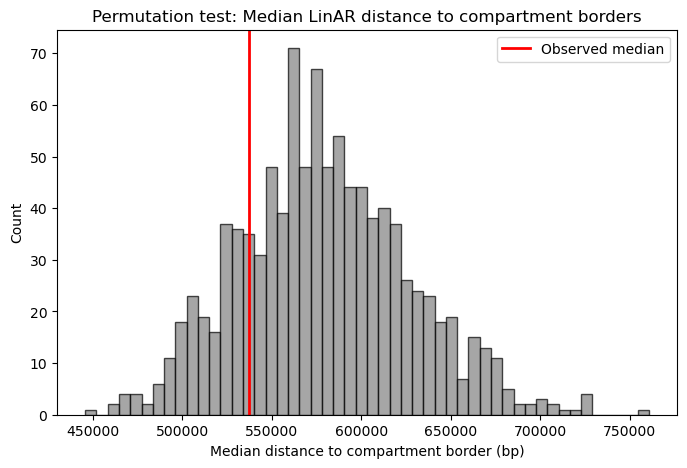

In [ ]:
# Permutation test with shuffled LinARs (median)

# Number of permutations
n_perm = 1000
x_chrom_length = 156040895

observed_distances = linar_compartment_border_distances["Distance_to_compartment_border"].values
observed_median = np.median(observed_distances)

perm_medians = []

for perm in range(n_perm):
    shuffled_distances = []

    for _, LinAR in ape_LinARs_chrX_unique.iterrows():
        length = LinAR["End"] - LinAR["Start"]
        random_start = np.random.randint(0, x_chrom_length - length)
        random_end = random_start + length

        overlapping_compartments = compartment_chrX[
            (random_start < compartment_chrX['end']) &
            (random_end > compartment_chrX['start'])
        ]

        if len(overlapping_compartments) > 1:
            distance_to_border = 0
        else:
            compartment = overlapping_compartments.iloc[0]
            distance_to_start = random_start - compartment["start"]
            distance_to_end   = compartment["end"] - random_end
            distance_to_border = min(distance_to_start, distance_to_end)

        shuffled_distances.append(distance_to_border)

    perm_medians.append(np.median(shuffled_distances))

perm_medians = np.array(perm_medians)

# Plot permutation distribution
plt.figure(figsize=(8,5))
plt.hist(perm_medians, bins=50, color='gray', alpha=0.7, edgecolor='black')
plt.axvline(observed_median, color='red', linewidth=2, label='Observed median')
plt.xlabel("Median distance to compartment border (bp)")
plt.ylabel("Count")
plt.title("Permutation test: Median LinAR distance to compartment borders")
plt.legend()
plt.show()



In [182]:
print(f"Observed median distance: {observed_median:.0f} bp")
print(f"Median of permuted median distances: {np.median(perm_medians):.0f} bp")
print(f"Mean of permuted median distances: {np.mean(perm_medians):.0f} bp")

# Empirical p-value: fraction of permuted medians <= observed median
p_value = (np.sum(perm_medians <= observed_median) + 1) / (n_perm + 1)
print(f"Empirical p-value: {p_value:.4f}")


Observed median distance: 537204 bp
Median of permuted median distances: 575940 bp
Mean of permuted median distances: 578931 bp
Empirical p-value: 0.1998


Observed mean distance: 1219668 bp
Mean of permuted distances (random nucleotides): 1738667 bp
Empirical p-value: 0.0010


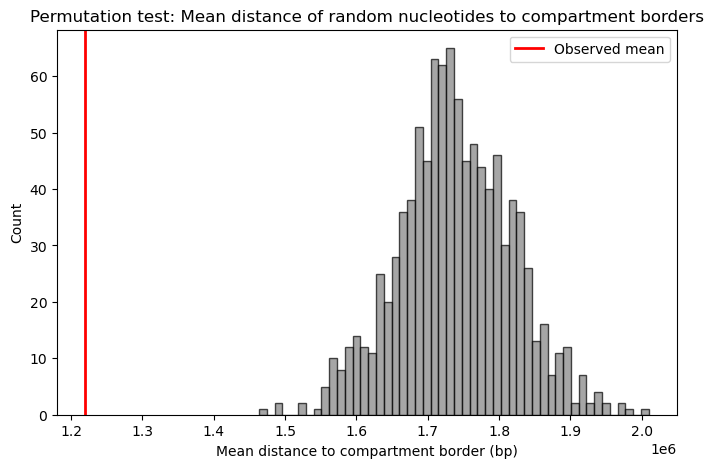

In [ ]:
# Permutation test with random chrX positions

# Number of permutations
n_perm = 1000
x_chrom_length = 156040895

n_random_positions = len(ape_LinARs_chrX_unique)  # same number as LinARs

observed_distances = linar_compartment_border_distances["Distance_to_compartment_border"].values
observed_mean = observed_distances.mean()

perm_means = []

for perm in range(n_perm):

    random_positions = np.random.randint(0, x_chrom_length, size=n_random_positions)

    distances = []

    for pos in random_positions:
        overlapping_compartments = compartment_chrX[
            (pos >= compartment_chrX['start']) & (pos <= compartment_chrX['end'])
        ]
        if len(overlapping_compartments) > 1:
            distance_to_border = 0
        else:
            compartment = overlapping_compartments.iloc[0]
            distance_to_start = pos - compartment["start"]
            distance_to_end   = compartment["end"] - pos
            distance_to_border = min(distance_to_start, distance_to_end)

        distances.append(distance_to_border)

    perm_means.append(np.mean(distances))

perm_means = np.array(perm_means)

# Empirical p-value: fraction of permuted means <= observed mean
p_value = (np.sum(perm_means <= observed_mean) + 1) / (n_perm + 1)
print(f"Observed mean distance: {observed_mean:.0f} bp")
print(f"Mean of permuted distances (random nucleotides): {perm_means.mean():.0f} bp")
print(f"Empirical p-value: {p_value:.4f}")

# Plot permutation distribution
plt.figure(figsize=(8,5))
plt.hist(perm_means, bins=50, color='gray', alpha=0.7, edgecolor='black')
plt.axvline(observed_mean, color='red', linewidth=2, label='Observed mean')
plt.xlabel("Mean distance to compartment border (bp)")
plt.ylabel("Count")
plt.title("Permutation test: Mean distance of random nucleotides to compartment borders")
plt.legend()
plt.show()


### Neuron gene distance to border

         LinAR_ID   Chr  Start_LinAR  End_LinAR Lineage_name Gene_name  \
0  HLinAR-Rank56*  chrX    138710262  138711758        Human     FGF13   
1   HLinAR-Rank87  chrX    103910029  103910206        Human   TMSB15B   
2  HLinAR-Rank157  chrX     71910623   71911026        Human     NHSL2   
3  HLinAR-Rank220  chrX    139142129  139142405        Human     FGF13   
4  HLinAR-Rank326  chrX     32928973   32929388        Human       DMD   

  Compartment  Compartment_start  Compartment_end  \
0           B        138700000.0      138750000.0   
1           B        103150000.0      104000000.0   
2           A         71800000.0       72750000.0   
3           A        139050000.0      139150000.0   
4           B         23150000.0       34700000.0   

   Distance_to_compartment_border  
0                           10262  
1                           89794  
2                          110623  
3                            7595  
4                         1770612  


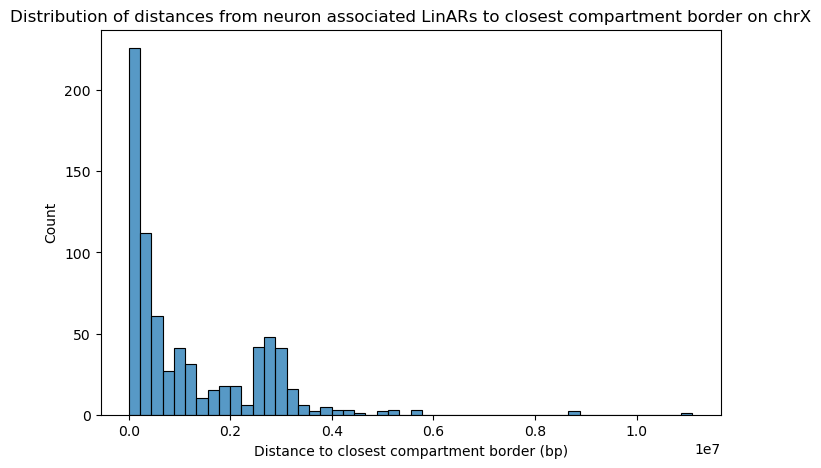

In [139]:

# Filter ape_LinARs_chrX to only contain LinARs associated with neuron_genes genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
neuron_genes = gene_list.get('neuron_genes') 
linars_neuron_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(neuron_genes)] 

# Calculate distances from neuron associated LinARs to compartment borders
results = []

for i, LinAR in linars_neuron_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find all compartments that the LinAR overlaps with
    overlapping_compartments = compartment_chrX[
        (LinAR_start < compartment_chrX['end']) & (LinAR_end > compartment_chrX['start'])
    ]

    if len(overlapping_compartments) > 1:
        # LinAR overlaps more than one compartment -> crosses border -> distance = 0
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan
    else:
        # LinAR overlaps exactly one compartment
        compartment = overlapping_compartments.iloc[0]

         # Fully inside one compartment
        distance_to_start = LinAR_start - compartment["start"]
        distance_to_end   = compartment["end"] - LinAR_end
        distance_to_border = min(distance_to_start, distance_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': LinAR['Chr'],
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR['Lineage_name'],
        'Gene_name': LinAR['Gene_name'],
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


neuron_linar_compartment_border_distances = pd.DataFrame(results)
print(neuron_linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=neuron_linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from neuron associated LinARs to closest compartment border on chrX")
plt.show()




### Neuron gene distance to border (include only each gene once (one LinAR for each gene))

     LinAR_ID   Chr  Start_LinAR  End_LinAR              Lineage_name  \
311  Rank1924  chrX     41349917   41350204        Hoolock leuconedys   
670   Rank209  chrX    154400282  154400412  Symphalangus syndactylus   
711   Rank473  chrX    154351273  154351380  Symphalangus syndactylus   
437  Rank1010  chrX    153051347  153051575             Nomascus siki   
387   Rank640  chrX     48448100   48448449             Nomascus siki   

    Gene_name Compartment  Compartment_start  Compartment_end  \
311     DDX3X     Overlap                NaN              NaN   
670     RPL10           A        154400000.0      154450000.0   
711      FLNA           B        154350000.0      154400000.0   
437     PNMA3           B        153050000.0      153150000.0   
387   SLC38A5           B         48350000.0       48450000.0   

     Distance_to_compartment_border  
311                               0  
670                             282  
711                            1273  
437               

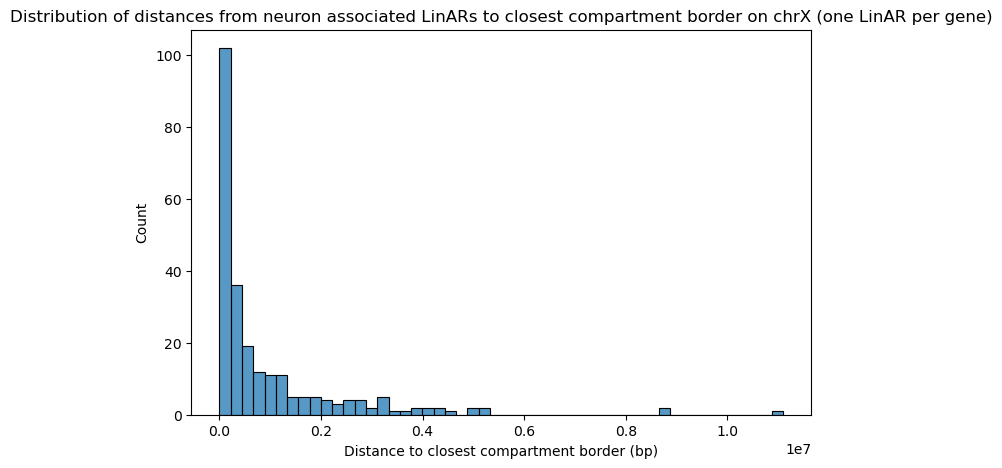

In [140]:

# For each gene, find all associated LinARs. Pick the LinAR with the shortest distance to compartment border. Discard all other LinARs for that gene
# -> one LinAR per gene
neuron_linar_closest_per_gene = (
    neuron_linar_compartment_border_distances
    .sort_values("Distance_to_compartment_border")
    .drop_duplicates(subset="Gene_name", keep="first")
)

print(neuron_linar_closest_per_gene.head())

# Plot distribution of absolute distances 
plt.figure(figsize=(8,5))
sns.histplot(
    data=neuron_linar_closest_per_gene, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from neuron associated LinARs to closest compartment border on chrX (one LinAR per gene)")
plt.show()





### Spermatid gene distance to border

         LinAR_ID   Chr  Start_LinAR  End_LinAR Lineage_name Gene_name  \
0  HLinAR-Rank56*  chrX    138710262  138711758        Human     FGF13   
1  HLinAR-Rank157  chrX     71910623   71911026        Human     NHSL2   
2  HLinAR-Rank220  chrX    139142129  139142405        Human     FGF13   
3  HLinAR-Rank326  chrX     32928973   32929388        Human       DMD   
4  HLinAR-Rank395  chrX     71597728   71597844        Human      GCNA   

  Compartment  Compartment_start  Compartment_end  \
0           B        138700000.0      138750000.0   
1           A         71800000.0       72750000.0   
2           A        139050000.0      139150000.0   
3           B         23150000.0       34700000.0   
4           A         63250000.0       71650000.0   

   Distance_to_compartment_border  
0                           10262  
1                          110623  
2                            7595  
3                         1770612  
4                           52156  


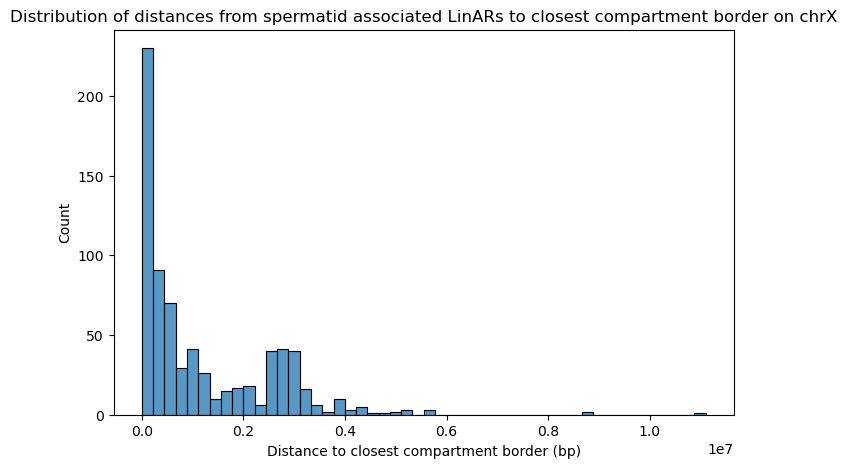

In [ ]:

# Filter ape_LinARs_chrX to only contain LinARs associated with human_spermatid_expressed_genes genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
human_spermatid_expressed_genes = gene_list.get('human_spermatid_expressed_genes') 
linars_spermatid_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(human_spermatid_expressed_genes)] 


# Calculate distances from neuron associated LinARs to compartment borders
results = []

for i, LinAR in linars_spermatid_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find all compartments that the LinAR overlaps with
    overlapping_compartments = compartment_chrX[
        (LinAR_start < compartment_chrX['end']) & (LinAR_end > compartment_chrX['start'])
    ]

    if len(overlapping_compartments) > 1:
        # LinAR overlaps more than one compartment -> crosses border -> distance = 0
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan
    else:
        # LinAR overlaps exactly one compartment
        compartment = overlapping_compartments.iloc[0]

         # Fully inside one compartment
        distance_to_start = LinAR_start - compartment["start"]
        distance_to_end   = compartment["end"] - LinAR_end
        distance_to_border = min(distance_to_start, distance_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': LinAR['Chr'],
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR['Lineage_name'],
        'Gene_name': LinAR['Gene_name'],
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


spermatid_linar_compartment_border_distances = pd.DataFrame(results)
print(spermatid_linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=spermatid_linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from spermatid associated LinARs to closest compartment border on chrX")
plt.show()




### Spermatid gene distance to border (one LinAR per gene)

     LinAR_ID   Chr  Start_LinAR  End_LinAR              Lineage_name  \
302  Rank1924  chrX     41349917   41350204        Hoolock leuconedys   
667   Rank209  chrX    154400282  154400412  Symphalangus syndactylus   
701   Rank473  chrX    154351273  154351380  Symphalangus syndactylus   
20     Rank92  chrX     75201718   75201741                 Hominidae   
417   Rank960  chrX    130154098  130154766             Nomascus siki   

    Gene_name Compartment  Compartment_start  Compartment_end  \
302     DDX3X     Overlap                NaN              NaN   
667     RPL10           A        154400000.0      154450000.0   
701      FLNA           B        154350000.0      154400000.0   
20      ABCB7           B         75200000.0       75250000.0   
417     AIFM1           B        130150000.0      130450000.0   

     Distance_to_compartment_border  
302                               0  
667                             282  
701                            1273  
20                

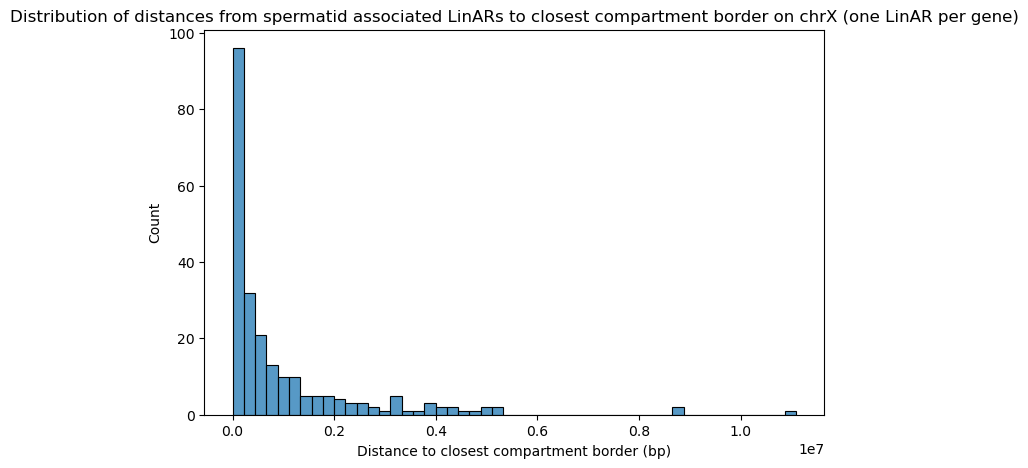

In [ ]:

# For each gene, find all associated LinARs. Pick the LinAR with the shortest distance to compartment border. Discard all other LinARs for that gene
# -> one LinAR per gene
spermatid_linar_closest_per_gene = (
    spermatid_linar_compartment_border_distances
    .sort_values("Distance_to_compartment_border")
    .drop_duplicates(subset="Gene_name", keep="first")
)

print(spermatid_linar_closest_per_gene.head())

# Plot distribution of absolute distances 
plt.figure(figsize=(8,5))
sns.histplot(
    data=spermatid_linar_closest_per_gene, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from spermatid associated LinARs to closest compartment border on chrX (one LinAR per gene)")
plt.show()



In [ ]:
linar_compartment_border_distances

,LinAR_ID,Chr,Start_LinAR,End_LinAR,Lineage_name,Gene_name,Compartment,Compartment_start,Compartment_end,Distance_to_compartment_border
0,Rank274,chrX,2852811,2852997,Hylobates pileatus,GYG2,A,2850000.0,2900000.0,2811
1,Rank441,chrX,2853528,2853637,Hylobates pileatus,GYG2,A,2850000.0,2900000.0,3528
2,Rank1099,chrX,5890030,5890143,Hylobates pileatus,NLGN4X,A,5850000.0,5900000.0,9857
3,Rank631,chrX,5890281,5890412,Hylobates pileatus,NLGN4X,A,5850000.0,5900000.0,9588
4,Rank443,chrX,7001766,7001876,Hominidae,PUDP,A,7000000.0,7050000.0,1766
...,...,...,...,...,...,...,...,...,...,...
724,Rank442,chrX,155290197,155290334,Symphalangus syndactylus,CLIC2,A,155250000.0,155300000.0,9666
725,Rank468,chrX,155290556,155290897,Gorilla gorilla,CLIC2,A,155250000.0,155300000.0,9103
726,Rank264,chrX,155290556,155290897,Symphalangus syndactylus,CLIC2,A,155250000.0,155300000.0,9103
727,Rank660,chrX,155292112,155292229,Symphalangus syndactylus,CLIC2,A,155250000.0,155300000.0,7771


### cDEG gene distance to border

  LinAR_ID   Chr  Start_LinAR  End_LinAR        Lineage_name Gene_name  \
0  Rank290  chrX    114933042  114933946           Hominidae     HTR2C   
1  Rank384  chrX     97471872   97471968           Hominidae    DIAPH2   
2  Rank113  chrX     41349917   41350204  Hylobates pileatus     DDX3X   
3  Rank132  chrX     41348697   41349048  Hylobates pileatus     DDX3X   
4  Rank240  chrX     41349357   41349722  Hylobates pileatus     DDX3X   

  Compartment  Compartment_start  Compartment_end  \
0           A        114800000.0      115000000.0   
1           B         76600000.0      100700000.0   
2     Overlap                NaN              NaN   
3           A         41250000.0       41350000.0   
4           A         41250000.0       41350000.0   

   Distance_to_compartment_border  
0                           66054  
1                         3228032  
2                               0  
3                             952  
4                             278  


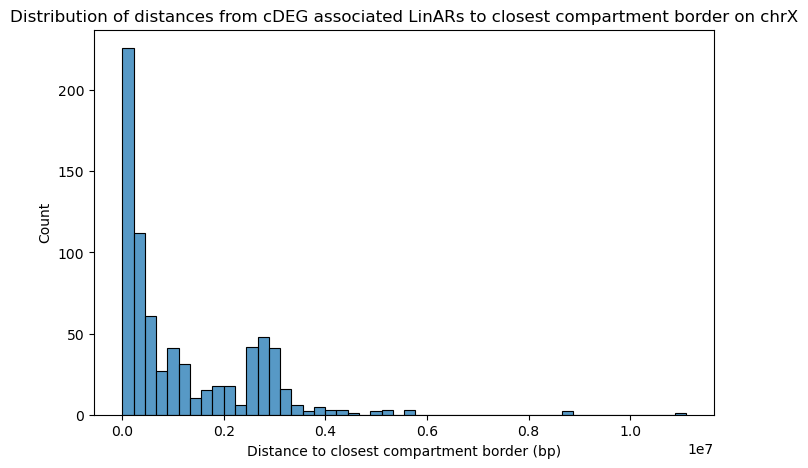

In [148]:

# Filter ape_LinARs_chrX to only contain LinARs associated with cDEG_human genes 
gene_list = GeneListCollection( "../data/cecilie_gen_lister.yaml") 
cDEG_human = gene_list.get('cDEG_human') 
linars_cDEG_df = ape_LinARs_chrX[ape_LinARs_chrX["Gene_name"].isin(cDEG_human)] 

# Calculate distances from neuron associated LinARs to compartment borders
results = []

for i, LinAR in linars_cDEG_df.iterrows():
    chrom = str(LinAR['Chr'])
    LinAR_start = LinAR['Start']
    LinAR_end = LinAR['End']

    # Find all compartments that the LinAR overlaps with
    overlapping_compartments = compartment_chrX[
        (LinAR_start < compartment_chrX['end']) & (LinAR_end > compartment_chrX['start'])
    ]

    if len(overlapping_compartments) > 1:
        # LinAR overlaps more than one compartment -> crosses border -> distance = 0
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan
    else:
        # LinAR overlaps exactly one compartment
        compartment = overlapping_compartments.iloc[0]

         # Fully inside one compartment
        distance_to_start = LinAR_start - compartment["start"]
        distance_to_end   = compartment["end"] - LinAR_end
        distance_to_border = min(distance_to_start, distance_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    
    results.append({
        'LinAR_ID': LinAR['LinAR_ID'],
        'Chr': LinAR['Chr'],
        'Start_LinAR': LinAR_start,
        'End_LinAR': LinAR_end,
        'Lineage_name': LinAR['Lineage_name'],
        'Gene_name': LinAR['Gene_name'],
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })


cDEG_linar_compartment_border_distances = pd.DataFrame(results)
print(cDEG_linar_compartment_border_distances.head())


# Plot distribution of absolute distances with Seaborn
plt.figure(figsize=(8,5))
sns.histplot(
    data=neuron_linar_compartment_border_distances, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from cDEG associated LinARs to closest compartment border on chrX")
plt.show()




### cDEG gene distance to border (one LinAR per gene)

   LinAR_ID   Chr  Start_LinAR  End_LinAR              Lineage_name Gene_name  \
2   Rank113  chrX     41349917   41350204        Hylobates pileatus     DDX3X   
42   Rank42  chrX    136210433  136210800  Symphalangus syndactylus      FHL1   
0   Rank290  chrX    114933042  114933946                 Hominidae     HTR2C   
10  Rank733  chrX     49199680   49199735        Hoolock leuconedys       SYP   
7   Rank435  chrX     36090444   36090715        Hylobates pileatus    CFAP47   

   Compartment  Compartment_start  Compartment_end  \
2      Overlap                NaN              NaN   
42           B        136200000.0      136250000.0   
0            A        114800000.0      115000000.0   
10           A         48450000.0       49300000.0   
7            B         35950000.0       36750000.0   

    Distance_to_compartment_border  
2                                0  
42                           10433  
0                            66054  
10                          100265  
7  

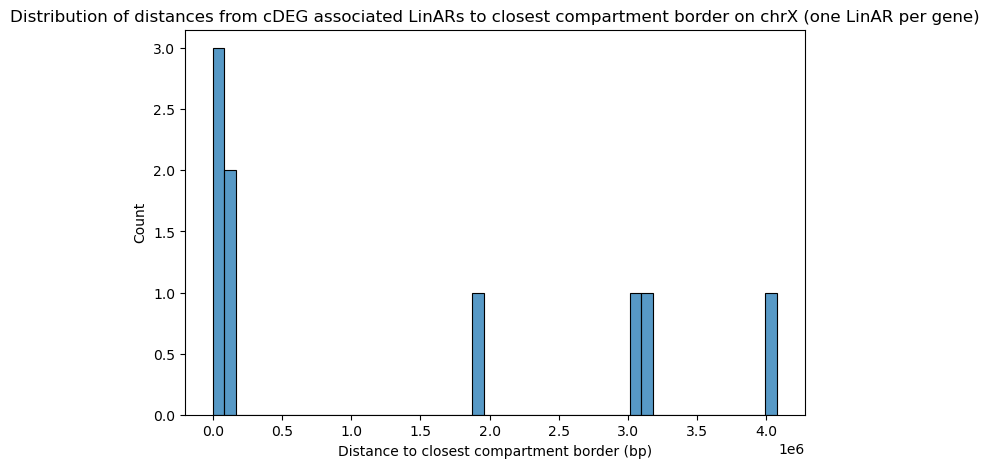

In [149]:

# For each gene, find all associated LinARs. Pick the LinAR with the shortest distance to compartment border. Discard all other LinARs for that gene
# -> one LinAR per gene
cDEG_linar_closest_per_gene = (
    cDEG_linar_compartment_border_distances
    .sort_values("Distance_to_compartment_border")
    .drop_duplicates(subset="Gene_name", keep="first")
)

print(cDEG_linar_closest_per_gene.head())

# Plot distribution of absolute distances 
plt.figure(figsize=(8,5))
sns.histplot(
    data=cDEG_linar_closest_per_gene, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from cDEG associated LinARs to closest compartment border on chrX (one LinAR per gene)")
plt.show()





### How close to borders are cDEG genes (associated with LinAR vs not associated with LinAR)

  Gene_name   Chr  Gene_start  Gene_end              Lineage_name Compartment  \
0     AKAP4  chrX    50190776  50201007  Symphalangus syndactylus     Overlap   
1     BRWD3  chrX    80669502  80809877  Symphalangus syndactylus           B   
2    CFAP47  chrX    35919733  36385317  Symphalangus syndactylus     Overlap   
3     DDX3X  chrX    41333307  41364472  Symphalangus syndactylus     Overlap   
4    DIAPH2  chrX    96684841  97604997  Symphalangus syndactylus           B   

   Compartment_start  Compartment_end  Distance_to_compartment_border  
0                NaN              NaN                               0  
1         76600000.0      100700000.0                       -32131883  
2                NaN              NaN                               0  
3                NaN              NaN                               0  
4         76600000.0      100700000.0                       -32131883  


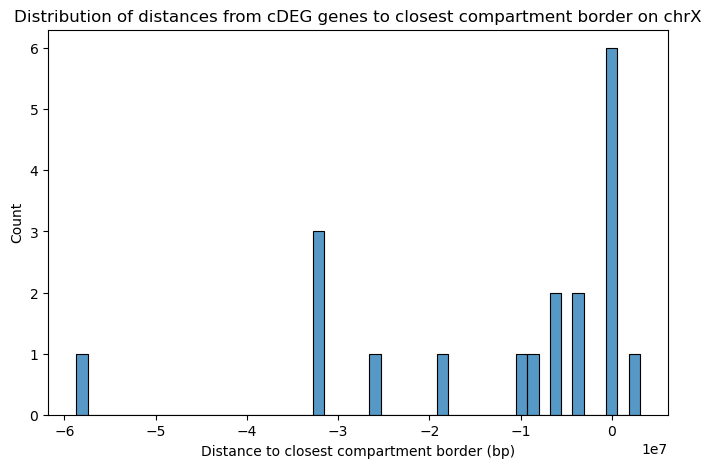

In [150]:
# Get gene coordiantes
gene_coords_cDEG = gene_coords(cDEG_human, assembly="hg38")

gene_coords_cDEG_df = pd.DataFrame(
    gene_coords_cDEG,
    columns=["Chr", "Gene_start", "Gene_end", "Gene_name"]
)
# Make sure it only contain chrX genes
gene_coords_cDEG_df = gene_coords_cDEG_df[gene_coords_cDEG_df["Chr"] == "chrX"]


gene_results = []

for i, gene in gene_coords_cDEG_df.iterrows():
    gene_start = gene['Gene_start']
    gene_end   = gene['Gene_end']

    # Find all compartments that the gene overlaps with
    overlapping_compartments = compartment_chrX[
        (gene_start < compartment_chrX['end']) & (gene_end > compartment_chrX['start'])
    ]

    if len(overlapping_compartments) > 1:
        # Gene overlaps more than one compartment -> crosses border -> distance = 0
        distance_to_border = 0
        compartment_type = "Overlap"
        compartment_start = np.nan
        compartment_end = np.nan
    else:
        # Gene overlaps exactly one compartment
        compartment = overlapping_compartments.iloc[0]

         # Fully inside one compartment
        distance_to_start = LinAR_start - compartment["start"]
        distance_to_end   = compartment["end"] - LinAR_end
        distance_to_border = min(distance_to_start, distance_to_end)
        compartment_type = compartment["compart"]
        compartment_start = compartment["start"]
        compartment_end = compartment["end"]
    
    gene_results.append({
        'Gene_name': gene['Gene_name'],
        'Chr': gene['Chr'],
        'Gene_start': gene_start,
        'Gene_end': gene_end,
        'Lineage_name': LinAR['Lineage_name'],
        'Compartment':  compartment_type,
        'Compartment_start': compartment_start,
        'Compartment_end': compartment_end,
        'Distance_to_compartment_border': distance_to_border
    })
    

gene_compartment_distances = pd.DataFrame(gene_results)
print(gene_compartment_distances.head())

# Plot distances
plt.figure(figsize=(8,5))
sns.histplot(
    data=gene_compartment_distances, 
    x='Distance_to_compartment_border', 
    bins=50, 
    kde=False, 
    edgecolor='black'
)
plt.xlabel("Distance to closest compartment border (bp)")
plt.ylabel("Count")
plt.title("Distribution of distances from cDEG genes to closest compartment border on chrX")
plt.show()


cDEG genes with LinARs: 9
cDEG genes without LinARs: 10
Total: 19


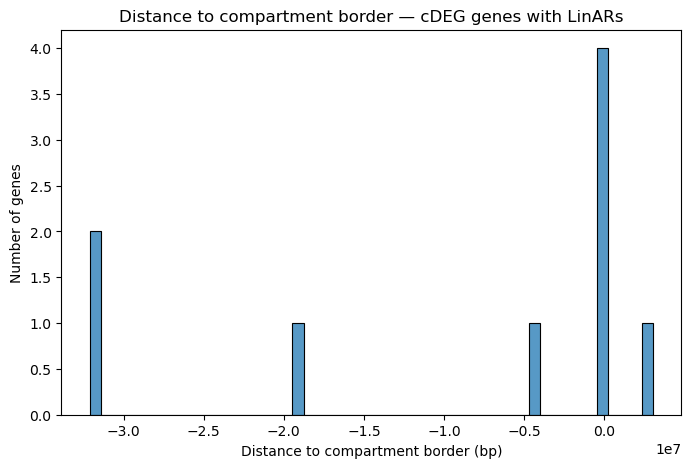

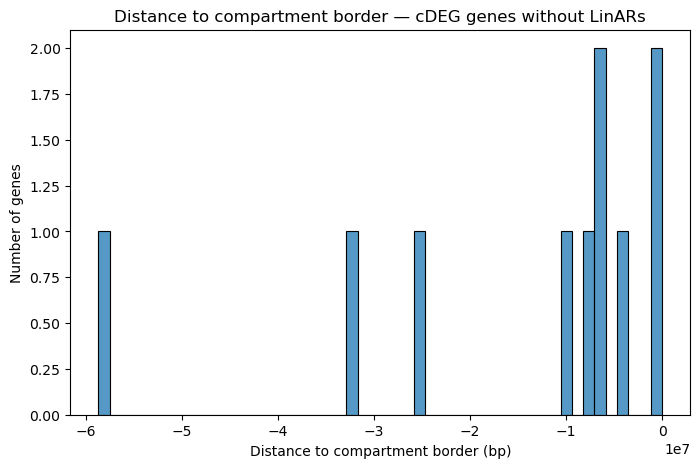

In [151]:
#cDEG associated with a LinAR vs cDEG not associated with LinAR 

cDEG_with_LinARs_list = set(linars_cDEG_df["Gene_name"].unique())

# Split gene_compartment_distances into two groups 
cDEG_with_LinARs_distances = gene_compartment_distances[
    gene_compartment_distances["Gene_name"].isin(cDEG_with_LinARs_list)
]
cDEG_without_LinARs_distances = gene_compartment_distances[
    ~gene_compartment_distances["Gene_name"].isin(cDEG_with_LinARs_list)
]

# Check sizez
print("cDEG genes with LinARs:", len(cDEG_with_LinARs_distances))
print("cDEG genes without LinARs:", len(cDEG_without_LinARs_distances))
print("Total:", len(gene_compartment_distances))


# Plot 1 — cDEG genes with LinARs 
plt.figure(figsize=(8,5))
sns.histplot(
    cDEG_with_LinARs_distances["Distance_to_compartment_border"],
    bins=50, 
    edgecolor='black'
)
plt.xlabel("Distance to compartment border (bp)")
plt.ylabel("Number of genes")
plt.title("Distance to compartment border — cDEG genes with LinARs")
plt.show()


# Plot 2 — cDEG genes without LinARs 
plt.figure(figsize=(8,5))
sns.histplot(
    cDEG_without_LinARs_distances["Distance_to_compartment_border"],
    bins=50, 
    edgecolor='black'
)
plt.xlabel("Distance to compartment border (bp)")
plt.ylabel("Number of genes")
plt.title("Distance to compartment border — cDEG genes without LinARs")
plt.show()